done
Entered compute fixedbottomcomponent


KeyboardInterrupt: 

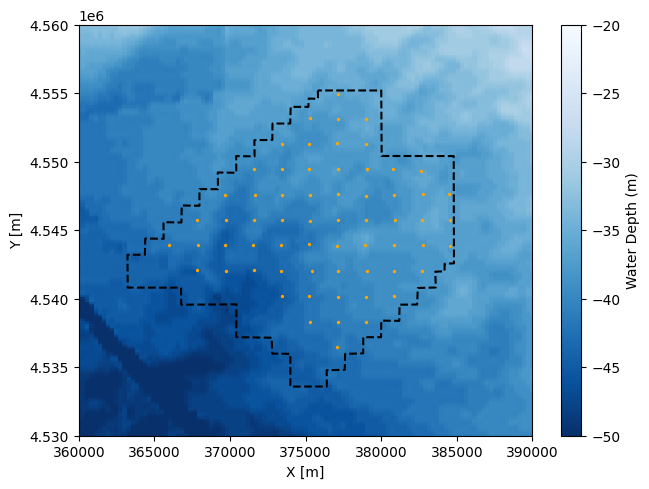

In [4]:
#############################################################################
import matplotlib.pyplot as plt

# WESL imports
# from wesl.offshore_wind_farms.revolution_wind import x_revwind, y_revwind, boundary_revwind, SG_110_200_DD, Revolutionwind_southforkwind
from wesl.offshore_wind_farms.vineyard_wind import x_vineyard, y_vineyard, boundary_vineyard, SG_14222, VineyardWind

from wesl.optimizer.constraints.wind_farm_constraints import BoundaryConstraint, PairWiseSpacing
from wesl.optimizer.offshore_system.wind_system import FixedBottomWindFarm


# WESL optimizer external dependencies
import numpy as np
import openmdao.api as om
from IPython.display import display

# AEP Calculator: PyWake Dependencies
from py_wake.literature.gaussian_models import Bastankhah_PorteAgel_2014
from wesl.utils.plot import get_water_depth_map

##########################################################################################
# Box encompassing Revolution Wind
min_lon, max_lon, min_lat, max_lat = -71.8, -70.2, 40.7, 41.4

# Getting longitude and latitude resolution, and interpolated elevation
water_depth_map_params = get_water_depth_map(water_depth_data="test3.nc",
                                             min_lon = min_lon,
                                             max_lon = max_lon,
                                             min_lat = min_lat,
                                             max_lat = max_lat)

##########################################################################################
# Instantiating boundary and layout coordinates
# boundary = boundary_revwind
# x_coordinates, y_coordinates = x_revwind, y_revwind
boundary = boundary_vineyard
x_coordinates, y_coordinates = x_vineyard, y_vineyard


##########################################################################################
# AEP computations: Low-order wake model, wind turbine, and site from PyWake
# wind_turbines = SG_110_200_DD()                              # wind turbine object
# site = Revolutionwind_southforkwind()                        # Uniform Weibull object
wind_turbines = SG_14222()                              # wind turbine object
site = VineyardWind()                        # Uniform Weibull object



sim_res = Bastankhah_PorteAgel_2014(site,                    # Wind farm model        
                                    wind_turbines, 
                                    k=0.0324555)
aep_init = sim_res(x_coordinates, y_coordinates).aep().sum() # AEP initial layout

# Defining the OpenMDAO optimization problem
prob = om.Problem()

# Adding subsystems and connections between them
# prob.model.add_subsystem('FBWF', 
#                          FixedBottomWindFarm(layout_coordinates = np.array([x_coordinates,
#                                                                             y_coordinates]),
#                                              sim_res = Bastankhah_PorteAgel_2014(site, 
#                                                                                  wind_turbines, 
#                                                                                  k=0.0324555), 
#                                             boundary = boundary, 
#                                             # layout_coordinates = np.array([x_coordinates,y_coordinates]),
#                                             lon_grid_fine = water_depth_map_params[0],
#                                             lat_grid_fine = water_depth_map_params[1],
#                                             interpolated_elevation = water_depth_map_params[2]),
#                          promotes_inputs=['x', 'y'])

prob.model.add_subsystem('FBWF', 
                         FixedBottomWindFarm(layout_coordinates = np.array([x_coordinates,
                                                                            y_coordinates]),
                                             sim_res = Bastankhah_PorteAgel_2014(site, 
                                                                                 wind_turbines, 
                                                                                 k=0.0324555), 
                                            boundary = boundary, 
                                            # layout_coordinates = np.array([x_coordinates,y_coordinates]),
                                            lon_grid_fine = water_depth_map_params[0],
                                            lat_grid_fine = water_depth_map_params[1],
                                            interpolated_elevation = water_depth_map_params[2],
                                            plot_lim = np.array([360000, 390000, 4.53E6, 4.56E6]),
                                            aep_init = aep_init,
                                            ),
                         promotes_inputs=['x', 'y'])


        # self.ax.set_xlim(360000, 390000)
        # self.ax.set_ylim(4.53E6, 4.56E6)


prob.model.add_subsystem('Spacing_Constraint', 
                         PairWiseSpacing(n_turbines = 63, 
                                         min_spacing = 5*wind_turbines.diameter()), 
                         promotes_inputs=['x', 'y'])


prob.model.add_subsystem('Boundary_Constraint',
                         BoundaryConstraint(polygon_vertices = boundary,
                                            number_of_turbines = 63),
                         promotes_inputs=['x','y']
)

# Driver setup
prob.driver = om.ScipyOptimizeDriver(tol = 1e-9)
# prob.driver.options['optimizer'] = 'COBYLA'
prob.driver.options['optimizer'] = 'SLSQP'
prob.driver.options['maxiter'] = 5
prob.driver.options['disp'] = False

# Input defaults ? (double check)
prob.model.set_input_defaults('x', x_coordinates)
prob.model.set_input_defaults('y', y_coordinates)

# Design variables
prob.model.add_design_var('x', 
                          lower=min(boundary[:,0]), 
                          upper=max(boundary[:,0]), 
                          scaler=0.01)

prob.model.add_design_var('y', 
                          lower=min(boundary[:,1]), 
                          upper=max(boundary[:,1]), 
                          scaler=0.01)

# Objective function
prob.model.add_objective('FBWF.AEP',  scaler=0.01)

# Setting constraints ? (double check)
prob.model.add_constraint('Spacing_Constraint.spacing_violation', scaler=0.01)
prob.model.add_constraint('Boundary_Constraint.boundary_cons', upper=0.0) # Feasibility condition: <= 0 ?

# Setup the problem with all the constraints, design variables, and objective
prob.setup()

# Run the optimization
prob.run_driver()

# Plotting the farm/cables/substantion layout and water depth
display(prob.model.FixedBottomWindFarm.fig)





In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use("default")
plt.close('all')

In [3]:
#############################################################################
import matplotlib.pyplot as plt

# WESL imports
# from wesl.offshore_wind_farms.revolution_wind import x_revwind, y_revwind, boundary_revwind, SG_110_200_DD, Revolutionwind_southforkwind
from wesl.offshore_wind_farms.vineyard_wind import x_vineyard, y_vineyard, boundary_vineyard, SG_14222, VineyardWind

from wesl.optimizer.constraints.wind_farm_constraints import BoundaryConstraint, PairWiseSpacing
from wesl.optimizer.offshore_system.wind_system import FixedBottomWindFarm


# WESL optimizer external dependencies
import numpy as np
import openmdao.api as om
from IPython.display import display

# AEP Calculator: PyWake Dependencies
from py_wake.literature.gaussian_models import Bastankhah_PorteAgel_2014
from wesl.utils.plot import get_water_depth_map

##########################################################################################
# Box encompassing Revolution Wind
min_lon, max_lon, min_lat, max_lat = -71.8, -70.2, 40.7, 41.4

# Getting longitude and latitude resolution, and interpolated elevation
water_depth_map_params = get_water_depth_map(water_depth_data="test3.nc",
                                             min_lon = min_lon,
                                             max_lon = max_lon,
                                             min_lat = min_lat,
                                             max_lat = max_lat)

##########################################################################################
# Instantiating boundary and layout coordinates
# boundary = boundary_revwind
# x_coordinates, y_coordinates = x_revwind, y_revwind
boundary = boundary_vineyard
x_coordinates, y_coordinates = x_vineyard, y_vineyard


##########################################################################################
# AEP computations: Low-order wake model, wind turbine, and site from PyWake
# wind_turbines = SG_110_200_DD()                              # wind turbine object
# site = Revolutionwind_southforkwind()                        # Uniform Weibull object
wind_turbines = SG_14222()                              # wind turbine object
site = VineyardWind()                        # Uniform Weibull object



sim_res = Bastankhah_PorteAgel_2014(site,                    # Wind farm model        
                                    wind_turbines, 
                                    k=0.0324555)
aep_init = sim_res(x_coordinates, y_coordinates).aep().sum() # AEP initial layout

# Defining the OpenMDAO optimization problem
prob = om.Problem()

# Adding subsystems and connections between them
# prob.model.add_subsystem('FBWF', 
#                          FixedBottomWindFarm(layout_coordinates = np.array([x_coordinates,
#                                                                             y_coordinates]),
#                                              sim_res = Bastankhah_PorteAgel_2014(site, 
#                                                                                  wind_turbines, 
#                                                                                  k=0.0324555), 
#                                             boundary = boundary, 
#                                             # layout_coordinates = np.array([x_coordinates,y_coordinates]),
#                                             lon_grid_fine = water_depth_map_params[0],
#                                             lat_grid_fine = water_depth_map_params[1],
#                                             interpolated_elevation = water_depth_map_params[2]),
#                          promotes_inputs=['x', 'y'])

prob.model.add_subsystem('FBWF', 
                         FixedBottomWindFarm(layout_coordinates = np.array([x_coordinates,
                                                                            y_coordinates]),
                                             sim_res = Bastankhah_PorteAgel_2014(site, 
                                                                                 wind_turbines, 
                                                                                 k=0.0324555), 
                                            boundary = boundary, 
                                            # layout_coordinates = np.array([x_coordinates,y_coordinates]),
                                            lon_grid_fine = water_depth_map_params[0],
                                            lat_grid_fine = water_depth_map_params[1],
                                            interpolated_elevation = water_depth_map_params[2],
                                            plot_lim = np.array([360000, 390000, 4.53E6, 4.56E6]),
                                            aep_init = aep_init,
                                            ),
                         promotes_inputs=['x', 'y'])


        # self.ax.set_xlim(360000, 390000)
        # self.ax.set_ylim(4.53E6, 4.56E6)


prob.model.add_subsystem('Spacing_Constraint', 
                         PairWiseSpacing(n_turbines = 63, 
                                         min_spacing = 5*wind_turbines.diameter()), 
                         promotes_inputs=['x', 'y'])


prob.model.add_subsystem('Boundary_Constraint',
                         BoundaryConstraint(polygon_vertices = boundary,
                                            number_of_turbines = 63),
                         promotes_inputs=['x','y']
)

# Driver setup
prob.driver = om.ScipyOptimizeDriver(tol = 1e-9)
# prob.driver.options['optimizer'] = 'COBYLA'
prob.driver.options['optimizer'] = 'SLSQP'
prob.driver.options['maxiter'] = 5
prob.driver.options['disp'] = False

# Input defaults ? (double check)
prob.model.set_input_defaults('x', x_coordinates)
prob.model.set_input_defaults('y', y_coordinates)

# Design variables
prob.model.add_design_var('x', 
                          lower=min(boundary[:,0]), 
                          upper=max(boundary[:,0]), 
                          scaler=0.01)

prob.model.add_design_var('y', 
                          lower=min(boundary[:,1]), 
                          upper=max(boundary[:,1]), 
                          scaler=0.01)

# Objective function
prob.model.add_objective('FBWF.AEP',  scaler=0.01)

# Setting constraints ? (double check)
prob.model.add_constraint('Spacing_Constraint.spacing_violation', scaler=0.01)
prob.model.add_constraint('Boundary_Constraint.boundary_cons', upper=0.0) # Feasibility condition: <= 0 ?

# Setup the problem with all the constraints, design variables, and objective
prob.setup()

# Run the optimization
prob.run_driver()


Entered compute fixedbottomcomponent


<Figure size 640x480 with 0 Axes>

[1569.89089805  737.71802732 1518.06533803 ...  805.60522451  785.6934259
 1584.42274517]
Optimization FAILED.
Iteration limit reached
-----------------------------------


Problem: problem2
Driver:  ScipyOptimizeDriver
  success     : False
  iterations  : 7
  runtime     : 1.0676E+01 s
  model_evals : 7
  model_time  : 3.5238E+00 s
  deriv_evals : 6
  deriv_time  : 6.9321E+00 s
  exit_status : FAIL